# Notebook 1 — EDA & Pre-processing

## Why this problem?
Toxic and hateful language online harms users, drives people away from communities, and increases moderation workload. An automatic **multi-label toxic-comment detector** can **assist (not replace)** human moderators by prioritising risky content and providing consistent signals for review.

## Dataset (what we use)
We use the **Kaggle Jigsaw Toxic Comment Classification** dataset
https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge

It is **multi-label**: each comment may have any combination of these six labels:
`toxic, severe_toxic, obscene, threat, insult, identity_hate`.  
The text column is the comment body (commonly `comment_text`).  
> **Content notice:** the dataset contains offensive language. We may mask examples in the notebook for readability, but the model trains on the raw cleaned text.

## What we want to learn from EDA
- **Data quality:** missing values, duplicates, weird formatting.
- **Text shape:** character/word length distribution → sensible max sequence length for models.
- **Imbalance:** how frequent each label is (some are rare, e.g., `threat`, `identity_hate`).
- **Co-occurrence:** which labels appear together (confirms this is truly multi-label).

## Cleaning policy (keep the signal)
Minimal, because slurs and spelling patterns are predictive:
- lowercase,
- replace URLs with `<url>`,
- strip simple HTML tags,
- collapse extra spaces,
- enforce labels to be 0/1,
- drop empty texts and **exact text duplicates**.
We **do not** remove profanity, emojis, or punctuation aggressively.

## Splitting (no leakage)
We create reproducible **80/10/10** Train/Validation/Test splits with a fixed seed.  
To keep distributions similar, we **stratify by the number of positive labels per row** (simple but effective for multi-label).  
All later models (TF-IDF+SVC, BiLSTM, DistilBERT) will **reuse these exact splits**.

## What this notebook saves (for the modelling notebooks)
- `processed/train.csv`, `processed/val.csv`, `processed/test.csv`
- `processed/meta.json` → text column name, label list, seed, row counts
- Figures for the report: **length histogram**, **label prevalence bar**, **co-occurrence heatmap**

## How this supports the rest of the project
- The cleaned splits prevent data leakage and make cross-model comparison fair.
- Length stats inform tokenisation choices (e.g., DistilBERT `max_length ≈ 256`).
- Imbalance observed here motivates our later choices: **`pos_weight`** in the loss and **per-label threshold tuning** on Validation.
- Final evaluation will report **Micro-F1, Macro-F1, per-label F1, PR-AUC (Mean PR-AUC)** and **Hamming Accuracy** (as requested by the assignment).

## Real-world application (where this is useful)
- **Moderation triage:** flag and prioritise comments likely to be toxic for human review.
- **Community health dashboards:** track trends by label (e.g., rise in threats).
- **Safety tooling:** pre-publish warnings or friction (e.g., “This may violate guidelines.”)

## Ethics & limits (short, honest note)
This model provides **assistive signals**, not final decisions. It can reflect dataset biases and may miss sarcasm or context outside a single comment. Human review remains essential; we mask offensive text in displays to minimise harm during assessment.

## Notebook link:
https://colab.research.google.com/drive/1wXoD9L4l3CYE0c9PYxENItd59XUoSzpT?usp=sharing

In [ ]:
# Mount Drive and set base paths
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/Colab_Notebooks/Assignment 3"
CSV_PATH = f"{BASE}/train.csv"
FIG_DIR = f"{BASE}/figures"
OUT_DIR = f"{BASE}/processed"

import os
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("BASE:", BASE)
print("CSV_PATH:", CSV_PATH)
print("FIG_DIR:", FIG_DIR)
print("OUT_DIR:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/drive/MyDrive/Colab_Notebooks/Assignment 3
CSV_PATH: /content/drive/MyDrive/Colab_Notebooks/Assignment 3/train.csv
FIG_DIR: /content/drive/MyDrive/Colab_Notebooks/Assignment 3/figures
OUT_DIR: /content/drive/MyDrive/Colab_Notebooks/Assignment 3/processed


In [ ]:
import re, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED)

pd.set_option("display.max_colwidth", 160)
sns.set(style="whitegrid")
print("Seed =", SEED)

Seed = 42


## Load the dataset and verify schema

We auto-detect the text column (common names) and assert the six label columns exist. If anything is missing, fail early with a clear error.

In [ ]:
assert os.path.exists(CSV_PATH), f"train.csv not found at: {CSV_PATH}"
df = pd.read_csv(CSV_PATH)
print("Loaded rows:", len(df))

CANDIDATE_TEXT = ["comment_text", "text", "comment", "body", "content"]
TEXT_COL = next((c for c in CANDIDATE_TEXT if c in df.columns), None)
assert TEXT_COL is not None, f"Text column not found. Tried: {CANDIDATE_TEXT}"

LABELS = ["toxic","severe_toxic","obscene","threat","insult","identity_hate"]
missing = [c for c in LABELS if c not in df.columns]
assert not missing, f"Missing label columns: {missing}"

print("Text column:", TEXT_COL)
print("Label columns:", LABELS)
df[[TEXT_COL] + LABELS].head(3)

Loaded rows: 159571
Text column: comment_text
Label columns: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at N...",0,0,0,0,0,0
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of m...",0,0,0,0,0,0


## Light text cleaning (keep the signal)

- lowercase  
- replace URLs with `<url>`  
- remove simple HTML tags  
- collapse extra spaces

Labels are coerced to integers in {0,1}. We then drop empty texts and exact duplicates (by text).

In [ ]:
def clean_text(s):
    s = "" if pd.isna(s) else str(s)
    s = s.lower()
    s = re.sub(r"http[s]?://\S+|www\.\S+", " <url> ", s)
    s = re.sub(r"<[^>]+>", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df = df.copy()
before = len(df)
df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

for c in LABELS:
    df[c] = df[c].fillna(0).astype(int).clip(0,1)

df = df[df[TEXT_COL].str.len() > 0]
after_empty = len(df)
df = df.drop_duplicates(subset=[TEXT_COL], keep="first")
after_dupe = len(df)

print("rows:", before, "→ after empty:", after_empty, "→ after de-dup:", len(df))

rows: 159571 → after empty: 159563 → after de-dup: 159288


## Quick masked preview (for human reading)

We only mask in the **display** (training uses the unmasked cleaned text).

In [ ]:
mask_terms = ["fuck","shit","bitch","asshole","bastard","cunt"]
pattern = r"\b(" + "|".join(re.escape(w) for w in mask_terms) + r")\b"

sample = df[[TEXT_COL] + LABELS].head(6).copy()
sample["preview_text"] = sample[TEXT_COL].str.replace(pattern, "***", regex=True, case=False)
sample[["preview_text"] + LABELS]

,preview_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,"explanation why the edits made under my username hardcore metallica fan were reverted? they weren't vandalisms, just closure on some gas after i voted at ne...",0,0,0,0,0,0
1,"d'aww! he matches this background colour i'm seemingly stuck with. thanks. (talk) 21:51, january 11, 2016 (utc)",0,0,0,0,0,0
2,"hey man, i'm really not trying to edit war. it's just that this guy is constantly removing relevant information and talking to me through edits instead of m...",0,0,0,0,0,0
3,""" more i can't make any real suggestions on improvement - i wondered if the section statistics should be later on, or a subsection of """"types of accidents""""...",0,0,0,0,0,0
4,"you, sir, are my hero. any chance you remember what page that's on?",0,0,0,0,0,0
5,""" congratulations from me as well, use the tools well. · talk """,0,0,0,0,0,0


In [ ]:
na = df[[TEXT_COL] + LABELS].isna().sum().sort_values(ascending=False)
print(na.to_string())

comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0


## Text length statistics and histogram

We keep this simple: character lengths and a quick histogram for distribution shape (helps later when choosing max sequence length).

char_len mean: 387.6 median: 201 p90: 877 max: 5000


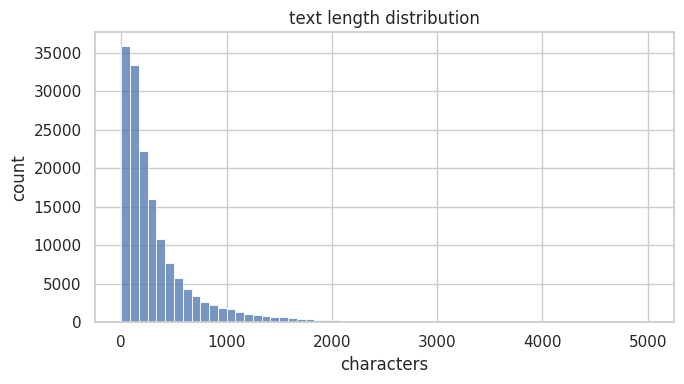

In [ ]:
df["char_len"] = df[TEXT_COL].str.len()
df["word_len"] = df[TEXT_COL].str.split().map(len)

print("char_len mean:", round(df["char_len"].mean(),1),
      "median:", int(df["char_len"].median()),
      "p90:", int(df["char_len"].quantile(0.9)),
      "max:", int(df["char_len"].max()))

plt.figure(figsize=(7,4))
sns.histplot(df["char_len"], bins=60)
plt.xlabel("characters")
plt.ylabel("count")
plt.title("text length distribution")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/length_hist.png", dpi=150)
plt.show()

## Label prevalence (class imbalance)

Counts and rates per label, plus a bar chart for the report. This motivates F1/PR-AUC later instead of accuracy alone.

counts:
 toxic            15246
severe_toxic      1590
obscene           8420
threat             474
insult            7850
identity_hate     1397

rates:
 toxic            0.0957
severe_toxic     0.0100
obscene          0.0529
threat           0.0030
insult           0.0493
identity_hate    0.0088


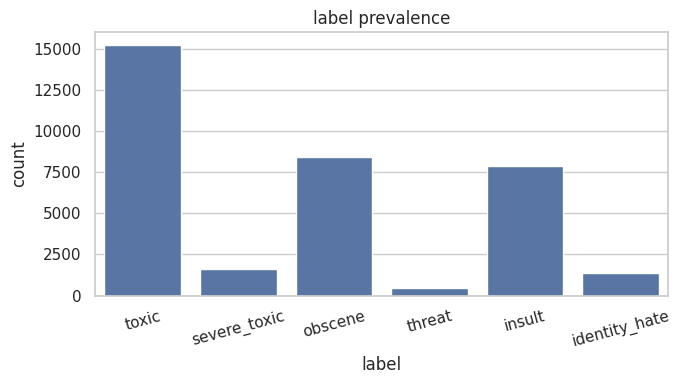

In [ ]:
counts = df[LABELS].sum().astype(int)
rates = (counts / len(df)).round(4)

print("counts:\n", counts.to_string())
print("\nrates:\n", rates.to_string())

plt.figure(figsize=(7,4))
sns.barplot(x=LABELS, y=[counts[l] for l in LABELS])
plt.ylabel("count")
plt.xlabel("label")
plt.title("label prevalence")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/prevalence_bar.png", dpi=150)
plt.show()

## Label co-occurrence heatmap

Shows which toxicities tend to appear together. Confirms the problem is **multi-label** rather than multi-class.

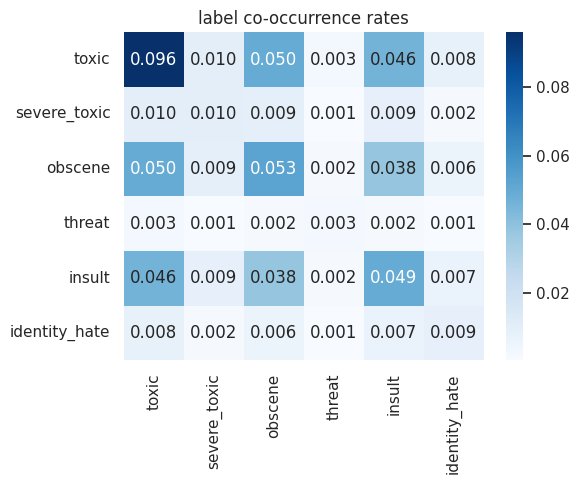

In [ ]:
Y = df[LABELS].values
co_counts = Y.T @ Y
co_rates = co_counts / len(df)
co_df = pd.DataFrame(co_rates, index=LABELS, columns=LABELS)

plt.figure(figsize=(6,5))
sns.heatmap(co_df, annot=True, fmt=".3f", cmap="Blues")
plt.title("label co-occurrence rates")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cooccurrence_heatmap.png", dpi=150)
plt.show()

## Train / Validation / Test split (80 / 10 / 10)

To keep distributions similar across splits, we stratify by the **number of positive labels per row** (a simple but effective proxy).

In [ ]:
from sklearn.model_selection import train_test_split

label_count = df[LABELS].sum(axis=1)

train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=SEED, shuffle=True, stratify=label_count
)

temp_label_count = temp_df[LABELS].sum(axis=1)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, shuffle=True, stratify=temp_label_count
)

def prev(frame):
    return (frame[LABELS].sum() / len(frame)).round(4).to_dict()

print("sizes:", len(train_df), len(val_df), len(test_df))
print("overall:", prev(df))
print("train  :", prev(train_df))
print("val    :", prev(val_df))
print("test   :", prev(test_df))

sizes: 127430 15929 15929
overall: {'toxic': 0.0957, 'severe_toxic': 0.01, 'obscene': 0.0529, 'threat': 0.003, 'insult': 0.0493, 'identity_hate': 0.0088}
train  : {'toxic': 0.0956, 'severe_toxic': 0.0101, 'obscene': 0.0527, 'threat': 0.0031, 'insult': 0.0494, 'identity_hate': 0.0086}
val    : {'toxic': 0.0962, 'severe_toxic': 0.0099, 'obscene': 0.0544, 'threat': 0.0021, 'insult': 0.0478, 'identity_hate': 0.0094}
test   : {'toxic': 0.0958, 'severe_toxic': 0.0089, 'obscene': 0.0527, 'threat': 0.0028, 'insult': 0.0498, 'identity_hate': 0.0095}


## Save outputs to Google Drive

We save clean, reproducible splits and a small `meta.json` so the three modelling notebooks can reload everything consistently.

In [ ]:
train_df.to_csv(f"{OUT_DIR}/train.csv", index=False)
val_df.to_csv(f"{OUT_DIR}/val.csv", index=False)
test_df.to_csv(f"{OUT_DIR}/test.csv", index=False)

meta = {
    "text_col": TEXT_COL,
    "labels": LABELS,
    "seed": SEED,
    "rows": {
        "all": int(len(df)),
        "train": int(len(train_df)),
        "val": int(len(val_df)),
        "test": int(len(test_df))
    }
}
with open(f"{OUT_DIR}/meta.json","w") as f:
    json.dump(meta, f, indent=2)

print("saved:", f"{OUT_DIR}/train.csv, val.csv, test.csv, meta.json")

saved: /content/drive/MyDrive/Colab_Notebooks/Assignment 3/processed/train.csv, val.csv, test.csv, meta.json


## Notes for the report (quick bullets)

- Minimal cleaning retains harmful words because they are predictive.  
- Texts are mostly short; a starting `max_length=128` is reasonable (we can revisit).  
- Labels are imbalanced (e.g., `threat`, `identity_hate` are rare), so we will use **Micro-F1, Macro-F1, per-label F1, PR-AUC**, and **Hamming Accuracy** (to satisfy the assignment’s “accuracy ≥ 85%” note).  
- Splits use a fixed seed and a simple stratify-by-label-count proxy to avoid distribution drift.

**Next:**  
Notebook 2 — TF-IDF + LinearSVC (OvR)  
Notebook 3 — BiLSTM  
Notebook 4 — DistilBERT (final + interface)